# Analysis of 3k T cells from cancer

This is a copy of the part of the scirpy tutorial where iggytop is being integrated. For the full tutorial refer to the [scirpy documentation](https://scirpy.scverse.org/en/latest/tutorials/tutorial_3k_tcr.html) or its [source](https://github.com/scverse/scirpy/blob/main/docs/tutorials/tutorial_3k_tcr.ipynb)
Here, the script serves to test if the tutorial notebook runs as expected using the latest iggytop release.

In [1]:
import muon as mu
import scanpy as sc
import scirpy as ir

# temporary fix for deprecated matplotlib functionality
import IPython.display
from matplotlib_inline.backend_inline import set_matplotlib_formats

IPython.display.set_matplotlib_formats = set_matplotlib_formats

sc.set_figure_params(figsize=(4, 4))
sc.settings.verbosity = 2  # verbosity: errors (0), warnings (1), info (2), hints (3)

/home/dego/iggytop/.venv/lib/python3.13/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
sc.logging.print_header()

Package,Version
muon,0.1.7
scanpy,1.11.5
scirpy,0.24.0
matplotlib-inline,0.2.1
Component,Info
Python,"3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:16:10) [GCC 11.2.0]"
OS,Linux-6.6.87.2-microsoft-standard-WSL2+-x86_64-with-glibc2.39
CPU,"22 logical CPU cores, x86_64"
GPU,"ID: 0, NVIDIA RTX 2000 Ada Generation Laptop GPU, Driver: 596.47, Memory: 8188 MiB"
Updated,2026-07-13 09:40


In this tutorial, we re-analyze single-cell TCR/RNA-seq data from Wu et al. {cite}`Wu2020`.
generated on the 10x Genomics platform. The original dataset consists of >140k T cells
from 14 treatment-naive patients across four different types of cancer.
For this tutorial, to speed up computations, we use a downsampled version of 3k cells.

## Importing data

`Scirpy` natively supports reading {term}`IR` data from [Cellranger](https://support.10xgenomics.com/single-cell-gene-expression/software/pipelines/latest/what-is-cell-ranger) (10x), 
[TraCeR](https://github.com/Teichlab/tracer) (Smart-seq2)
or the [AIRR rearrangement schema](https://docs.airr-community.org/en/latest/datarep/rearrangements.html) and provides helper functions to import other data types. We provide a {ref}`dedicated tutorial on data loading <importing-data>` with more details.

:::{warning}
**scirpy's data structure has been updated in v0.13.0.**

Previously, receptor data was expanded into columns of `adata.obs`, now they are stored as an {term}`awkward array` in `adata.obsm["airr"]`. 
Moreover, we now use {class}`~mudata.MuData` to handle paired transcriptomics and {term}`AIRR` data. 

`AnnData` objects created with older versions of scirpy can be upgraded with {func}`scirpy.io.upgrade_schema` to be compatible with the latest version of scirpy.

Please check out

 * The {ref}`release notes <v0.13>` for details about the changes
 * The documentation about {ref}`Scirpy's data structure <data-structure>` and
 * {ref}`Scirpy's receptor model <receptor-model>`. 
:::


The example dataset for this tutorial ships with the `scirpy` package. We can conveniently load it from the {mod}`~scirpy.datasets` module: 

In [3]:
mdata = ir.datasets.wu2020_3k()

/home/dego/iggytop/.venv/lib/python3.13/site-packages/anndata/utils.py:362: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)
/home/dego/iggytop/.venv/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/dego/iggytop/.venv/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which 

`mdata` is a {class}`~mudata.MuData` object with two modalities: `gex` for gene expression and `airr` for immune-receptor data. 

In [4]:
mdata

MuData object with n_obs × n_vars = 3000 × 30727
  2 modalities
    gex:	3000 x 30727
      obs:	'cluster_orig', 'patient', 'sample', 'source'
      uns:	'cluster_orig_colors'
      obsm:	'X_umap_orig'
    airr:	3000 x 0
      obs:	'high_confidence', 'is_cell', 'clonotype_orig'
      obsm:	'airr'

## Preprocessing Transcriptomics data

Gene expression (GEX) data needs to be filtered and preprocessed as with any other single-cell dataset.
For this tutorial, we perform minimal preprocessing for demonstration purposes. For a real dataset, we recommend following the [scverse tutorials](https://scverse.org/learn/)
and the [single-cell best practice book](https://sc-best-practices.org/).

In [5]:
sc.pp.filter_genes(mdata["gex"], min_cells=10)
sc.pp.filter_cells(mdata["gex"], min_genes=100)

filtered out 18877 genes that are detected in less than 10 cells


In [6]:
sc.pp.normalize_per_cell(mdata["gex"])
sc.pp.log1p(mdata["gex"])
sc.pp.highly_variable_genes(mdata["gex"], flavor="cell_ranger", n_top_genes=5000)
sc.tl.pca(mdata["gex"])
sc.pp.neighbors(mdata["gex"])

normalizing by total count per cell
    finished (0:00:00): normalized adata.X and added
    'n_counts', counts per cell before normalization (adata.obs)
extracting highly variable genes


/tmp/ipykernel_52912/3237590329.py:1: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(mdata["gex"])
/home/dego/iggytop/.venv/lib/python3.13/site-packages/scanpy/preprocessing/_simple.py:590: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(


    finished (0:00:00)
computing PCA
    with n_comps=50
    finished (0:00:04)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished (0:00:04)


For the _Wu2020_ dataset, the authors already provide clusters and UMAP coordinates.
Instead of performing clustering and cluster annotation ourselves, we will just use
the provided data. The clustering and annotation methodology is
described in [their paper](https://doi.org/10.1038/s41586-020-2056-8).

In [7]:
mdata["gex"].obsm["X_umap"] = mdata["gex"].obsm["X_umap_orig"]

In [8]:
mapping = {
    "nan": "other",
    "3.1-MT": "other",
    "4.1-Trm": "CD4_Trm",
    "4.2-RPL32": "CD4_RPL32",
    "4.3-TCF7": "CD4_TCF7",
    "4.4-FOS": "CD4_FOSS",
    "4.5-IL6ST": "CD4_IL6ST",
    "4.6a-Treg": "CD4_Treg",
    "4.6b-Treg": "CD4_Treg",
    "8.1-Teff": "CD8_Teff",
    "8.2-Tem": "CD8_Tem",
    "8.3a-Trm": "CD8_Trm",
    "8.3b-Trm": "CD8_Trm",
    "8.3c-Trm": "CD8_Trm",
    "8.4-Chrom": "other",
    "8.5-Mitosis": "other",
    "8.6-KLRB1": "other",
}
mdata["gex"].obs["cluster"] = mdata["gex"].obs["cluster_orig"].map(mapping)

Now that we filtered obs and var of the GEX modality, we need to propagate those changes back to the `MuData` object.

In [9]:
mdata.update()

/home/dego/iggytop/.venv/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/dego/iggytop/.venv/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


## Query epitope databases


We can use scirpy to query reference databases or datasets to annotate {term}`IRs <IR>` with certain
features, such as epitope specificity. The reference database can be any dataset in {ref}`scirpy's AnnData format <data-structure>` and you can follow the instructions in the {ref}`data loading tutorial <importing-custom-formats>`
to build a custom reference database, if it is not available from {mod}`scirpy.datasets` yet.

Querying reference datasets uses the same logic as {ref}`defining clonotypes <define-clonotypes-tutorial>`:

```{eval-rst}
.. list-table:: Analysis steps on IR data
    :widths: 40 60
    :header-rows: 1

    - - scirpy function
      - objective
    - - :func:`scirpy.pp.ir_dist`
      - Compute sequence-based distance matrices .
    - - :func:`scirpy.tl.ir_query`
      - For each cell, identify matching entries in a reference database.
    - - :func:`scirpy.tl.ir_query_annotate`
      - Transfer annotations from reference database to `adata.obs`.
    - - :func:`scirpy.tl.ir_query_annotate_df`
      - Return a dataframe with all matching annotations.
```

Here, we obtain {func}`IggyTop <scirpy.datasets.iggytop>`, a metadatabase of multiple receptor databases
including IEDB and VDJdb, and annotate epitopes based on amino acid sequence identity. 
For demonstration purposes on this toy dataset we use rather lenient settings: For a match, we specify that it is enough that either of the {term}`VJ <V(D)J>` and {term}`VDJ <V(D)J>` sequences, and either of the primary or secondary receptor chains matches the database.


In [10]:

iggytop_tag = "data-2026.07.13.082648"
iggytop = ir.datasets.iggytop(tag=iggytop_tag)

In [11]:
ir.pp.ir_dist(mdata, iggytop, metric="identity", sequence="aa")

Filtering chains...
Indexing VJ chains...
Indexing VDJ chains...
build result array
Computing sequence x sequence distance matrix for VJ sequences.
Computing sequence x sequence distance matrix for VDJ sequences.


In [12]:
ir.tl.ir_query(
    mdata,
    iggytop,
    metric="identity",
    sequence="aa",
    receptor_arms="any",
    dual_ir="any",
)

Initializing lookup tables. 
Computing clonotype x clonotype distances.
Stored IR distance matrix in `adata.uns["ir_query_iggytop_deduplicated_aa_identity"]`.



{func}`~scirpy.tl.ir_query_annotate_df` allows us to retrieve *all pairs cells with their of matching entries*. If a cell matches multiple entires from the reference database, the resulting data frame will contain multiple rows for the same cell.


In [13]:
ir.tl.ir_query_annotate_df(
    mdata,
    iggytop,
    metric="identity",
    sequence="aa",
    include_ref_cols=["antigen_species", "antigen_name"],
)

,antigen_species,antigen_name
LN2_GCACTCTCAGGGATTG-2,Severe acute respiratory syndrome coronavirus 2,ORF7a protein
LN4_GAAACTCTCATCATTC-1,Severe acute respiratory syndrome coronavirus 2,ORF1ab
LN4_GAAACTCTCATCATTC-1,Severe acute respiratory syndrome coronavirus 2,ORF10
LN4_GAAACTCTCATCATTC-1,Influenza A virus,M
LN4_GAAACTCTCATCATTC-1,Cytomegalovirus,pp65
...,...,...
RT3_GCAGTTAGTATGAAAC-1,NaN,NaN
RT3_GCAGTTAGTATGAAAC-1,Homo sapiens,Wilms tumor protein
RT3_GCAGTTAGTATGAAAC-1,Epstein-Barr virus,EBNA 3B
RT3_GCAGTTAGTATGAAAC-1,Epstein-Barr virus,BZLF1



Alternatively, to break down the annotation to a single-value per cell, you can use
{func}`~scirpy.tl.ir_query_annotate`. Depending on the specified `strategy` it will only label unambiguous matches, or use the most frequent value.


In [14]:
ir.tl.ir_query_annotate(
    mdata,
    iggytop,
    metric="identity",
    sequence="aa",
    include_ref_cols=["antigen_species"],
    strategy="most-frequent",
)

  0%|          | 0/631 [00:00<?, ?it/s]

Stored result in `mdata.obs["airr:antigen_species"]`.


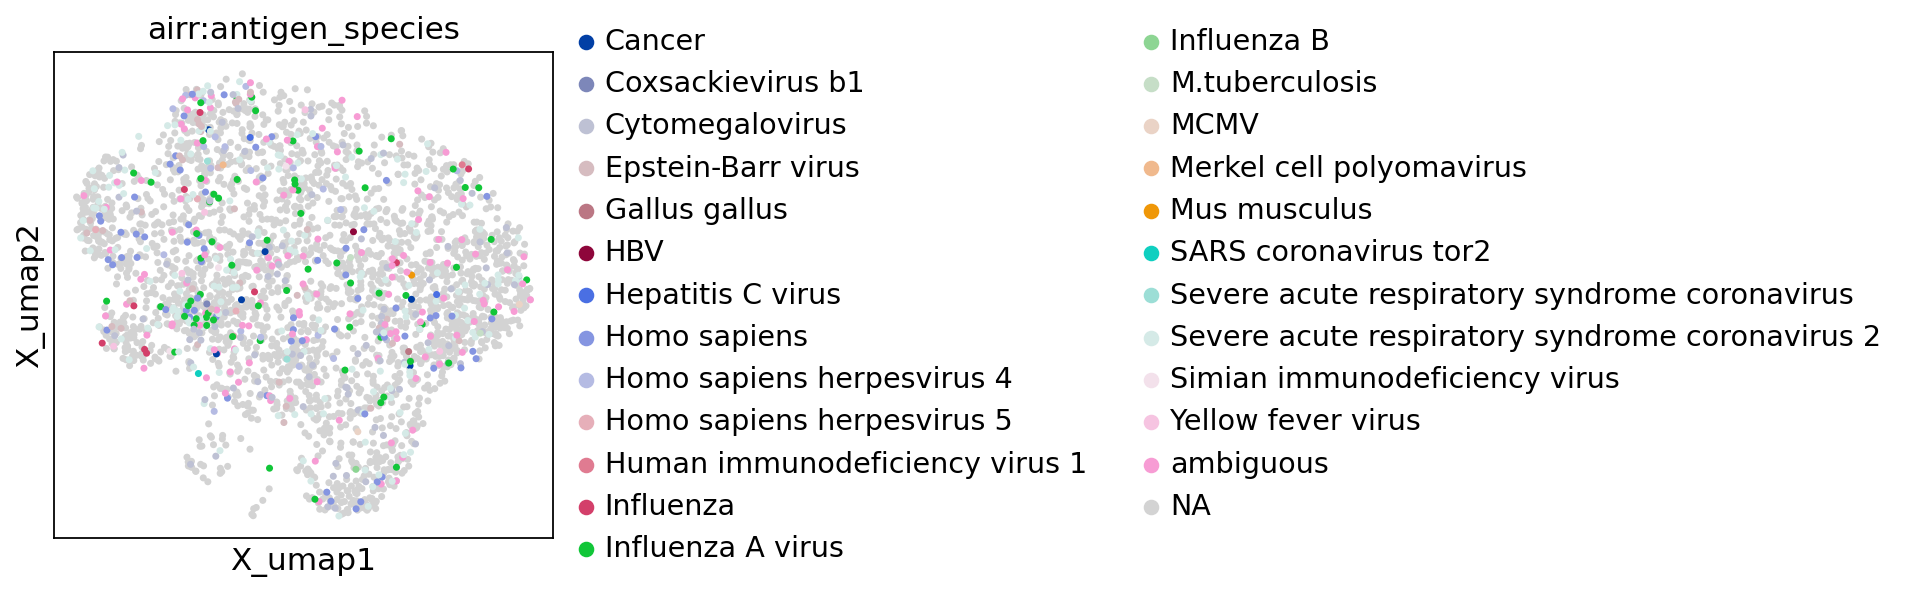

In [15]:
mu.pl.embedding(mdata, "gex:umap", color="airr:antigen_species")